In [1]:
import pandas as pd
import numpy as np

# Set seed agar data konsisten saat di-generate ulang
np.random.seed(42)
n_samples = 500  # Jumlah baris data anak

# 1. Membuat Fitur Prediktor (X)
frekuensi_dongeng = np.random.randint(0, 8, n_samples) # 0 sampai 7 kali seminggu
rasio_buku_bergambar = np.random.uniform(0.1, 1.0, n_samples) # Persentase buku ilustrasi
jam_gawai = np.random.uniform(0.5, 6.0, n_samples) # Durasi screen time per hari
pojok_baca = np.random.choice([0, 1], size=n_samples, p=[0.4, 0.6]) # Ada/Tidak ada di rumah

# 2. Membuat Logika Target Label (Y) berdasarkan aturan tertentu (biar model bisa belajar)
skor_logika = (frekuensi_dongeng * 1.5) + (rasio_buku_bergambar * 2) - (jam_gawai * 1.2) + (pojok_baca * 1.0)
target_minat_baca = np.where(skor_logika > np.median(skor_logika), 1, 0)

# 3. Gabungkan menjadi DataFrame
df = pd.DataFrame({
    'Frekuensi_Mendongeng_Mingguan': frekuensi_dongeng,
    'Rasio_Buku_Bergambar': np.round(rasio_buku_bergambar, 2),
    'Durasi_Gawai_Harian_Jam': np.round(jam_gawai, 1),
    'Ketersediaan_Pojok_Baca': pojok_baca,
    'Target_Minat_Baca': target_minat_baca
})

# 4. Simpan ke CSV untuk dieksekusi di Python atau KNIME
df.to_csv('minat_baca_anak.csv', index=False)
print("Dataset berhasil dibuat! Total data:", len(df))

Dataset berhasil dibuat! Total data: 500


=== PERFORMA MODEL KNN ===
Akurasi: 96.0%
              precision    recall  f1-score   support

           0       0.94      0.98      0.96        50
           1       0.98      0.94      0.96        50

    accuracy                           0.96       100
   macro avg       0.96      0.96      0.96       100
weighted avg       0.96      0.96      0.96       100


=== PERFORMA MODEL ADABOOST ===
Akurasi: 94.0%
              precision    recall  f1-score   support

           0       0.92      0.96      0.94        50
           1       0.96      0.92      0.94        50

    accuracy                           0.94       100
   macro avg       0.94      0.94      0.94       100
weighted avg       0.94      0.94      0.94       100



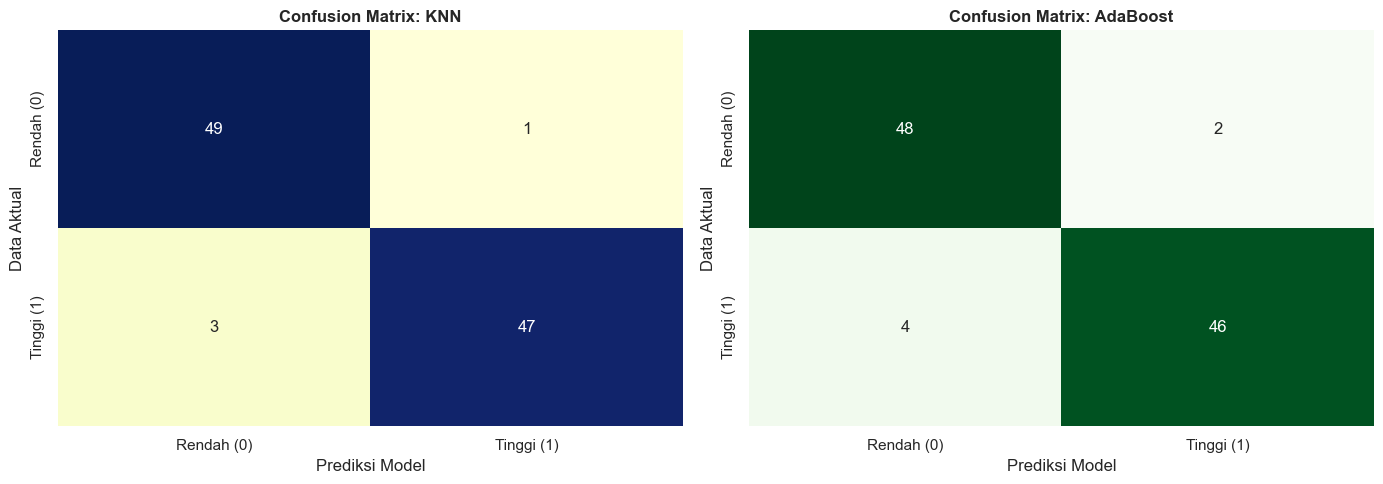

C:\Users\Acer\AppData\Local\Temp\ipykernel_1476\2676384397.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=features_ranked, palette='viridis')


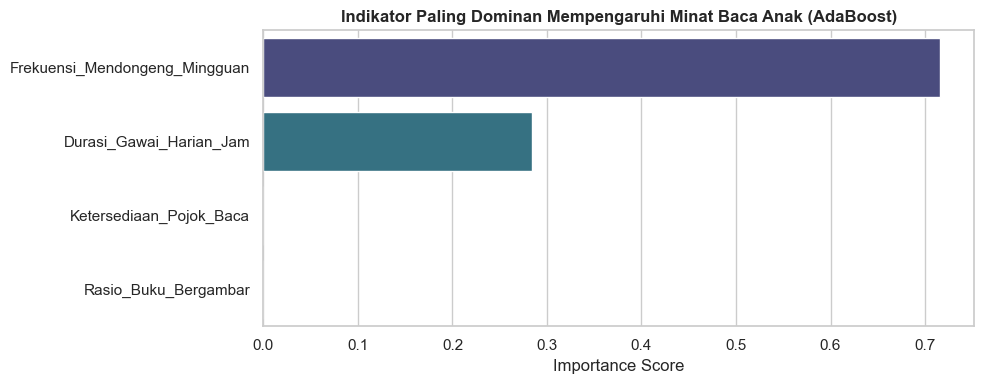

In [4]:
# ==========================================
# 2. PROSES MACHINE LEARNING & EVALUASI
# ==========================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Hubungkan visualisasi dengan backend Jupyter agar grafik otomatis muncul
%matplotlib inline
sns.set_theme(style="whitegrid")

# Pisahkan Fitur (X) dan Target Label (y)
X = df.drop(columns=['Target_Minat_Baca'])
y = df['Target_Minat_Baca']

# Bagi Data: 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Normalisasi Fitur dengan MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- MODEL 1: K-NEAREST NEIGHBORS (KNN) ---
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

# --- MODEL 2: ADABOOST CLASSIFIER ---
base_tree = DecisionTreeClassifier(max_depth=1, random_state=42)
adaboost = AdaBoostClassifier(estimator=base_tree, n_estimators=100, learning_rate=0.1, random_state=42)
adaboost.fit(X_train_scaled, y_train)
y_pred_ada = adaboost.predict(X_test_scaled)

# Tampilkan Laporan Hasil Performa Akurasi di Konsol
print("=== PERFORMA MODEL KNN ===")
print(f"Akurasi: {accuracy_score(y_test, y_pred_knn) * 100:.1f}%")
print(classification_report(y_test, y_pred_knn))

print("\n=== PERFORMA MODEL ADABOOST ===")
print(f"Akurasi: {accuracy_score(y_test, y_pred_ada) * 100:.1f}%")
print(classification_report(y_test, y_pred_ada))

# ==========================================
# 3. VISUALISASI SEABORN & MATPLOTLIB
# ==========================================
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot Confusion Matrix - KNN
cm_knn = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='YlGnBu', ax=ax[0], cbar=False)
ax[0].set_title(f'Confusion Matrix: KNN', fontsize=12, fontweight='bold')
ax[0].set_xlabel('Prediksi Model')
ax[0].set_ylabel('Data Aktual')
ax[0].set_xticklabels(['Rendah (0)', 'Tinggi (1)'])
ax[0].set_yticklabels(['Rendah (0)', 'Tinggi (1)'])

# Plot Confusion Matrix - AdaBoost
cm_ada = confusion_matrix(y_test, y_pred_ada)
sns.heatmap(cm_ada, annot=True, fmt='d', cmap='Greens', ax=ax[1], cbar=False)
ax[1].set_title(f'Confusion Matrix: AdaBoost', fontsize=12, fontweight='bold')
ax[1].set_xlabel('Prediksi Model')
ax[1].set_ylabel('Data Aktual')
ax[1].set_xticklabels(['Rendah (0)', 'Tinggi (1)'])
ax[1].set_yticklabels(['Rendah (0)', 'Tinggi (1)'])

plt.tight_layout()
plt.show()

# Plot Feature Importance (Faktor Paling Berpengaruh)
plt.figure(figsize=(10, 4))
importances = adaboost.feature_importances_
indices = np.argsort(importances)[::-1]
features_ranked = [X.columns[i] for i in indices]

sns.barplot(x=importances[indices], y=features_ranked, palette='viridis')
plt.title('Indikator Paling Dominan Mempengaruhi Minat Baca Anak (AdaBoost)', fontsize=12, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [3]:
!pip install scikit-learn seaborn matplotlib

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ------ --------------------------------- 1.3/8.2 MB 7.2 MB/s eta 0:00:01
   -------------- ------------------------- 2.9/8.2 MB 8.0 MB/s eta 0:00:01
   ----------------------- ---------------- 4.7/8.2 MB 8.4 MB/s eta 0:00:01
   ---------------------------- ----------- 5.8/8.2 MB 7.1 MB/s eta 0:00:01
   ------------------------------ --------- 6.3/8.2 MB 6.2 MB/s eta 0:00:01
   --------------------------------- ------ 6.8/8.2 MB 5.6 MB/s eta 0:00:01
   ----------------------------------- ---- 7.3/8.2 MB 5.0 MB/s eta 0:00:01
   ------------------------------------- -- 7.6/8.2 MB 4.5 MB/s eta 0:00:01
   ------------------------------------- -- 7.6/8.2 MB 4.5 MB/s eta 0:00:01
   -------------------------------------- - 7.9/8.2 MB 4.0 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 3.5 MB/s  0:00:02
   -----------------


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
